# Notebook for X-Ray Light curve model Project

In [2]:
from plot_results import *
from chandra_phase_analysis import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

In [3]:
# Generate model lightcurve in soft energy band
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv flux_vs_nH_phabs_soft.csv \
--output sim_flux_interpolate_phabs_soft.csv \
--i0 10.0 --lam 0.589454 --lam2 0.589454 --r 0.1 --R 10")

Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.1 solar radii
  R (companion radius): 10.0 solar radii
  d1 (emitter separation): 11.0 solar radii
  d2 (companion separation): 8.0 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 10.0 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: flux_vs_nH_phabs_soft.csv
  lam: 0.589454
  lam2: 0.589454
  Output file: sim_flux_interpolate_phabs_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to sim_flux_interpolate_phabs_soft.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:328: UserWarning: Some nH values are outside CSV range [0.000, 361.042] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(
/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:328: UserWarning: Some nH values are outside CSV range [0.000, 361.042] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(


0

Detected energy bands: ['soft']


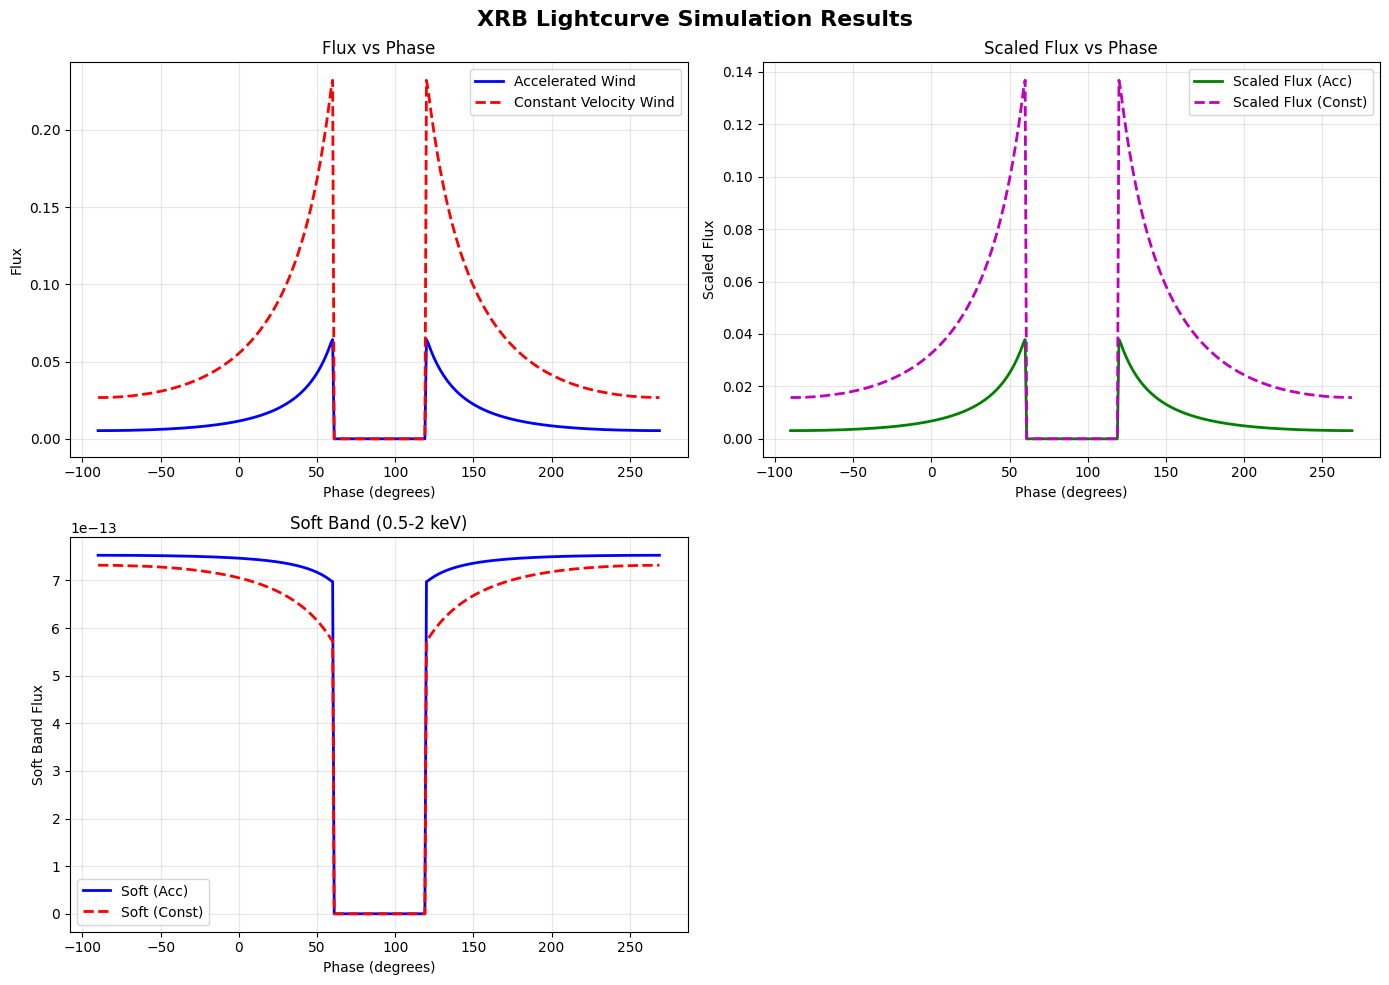

In [5]:
# Plot model Lightcurve
plot_lightcurve("sim_flux_interpolate_phabs_soft.csv")

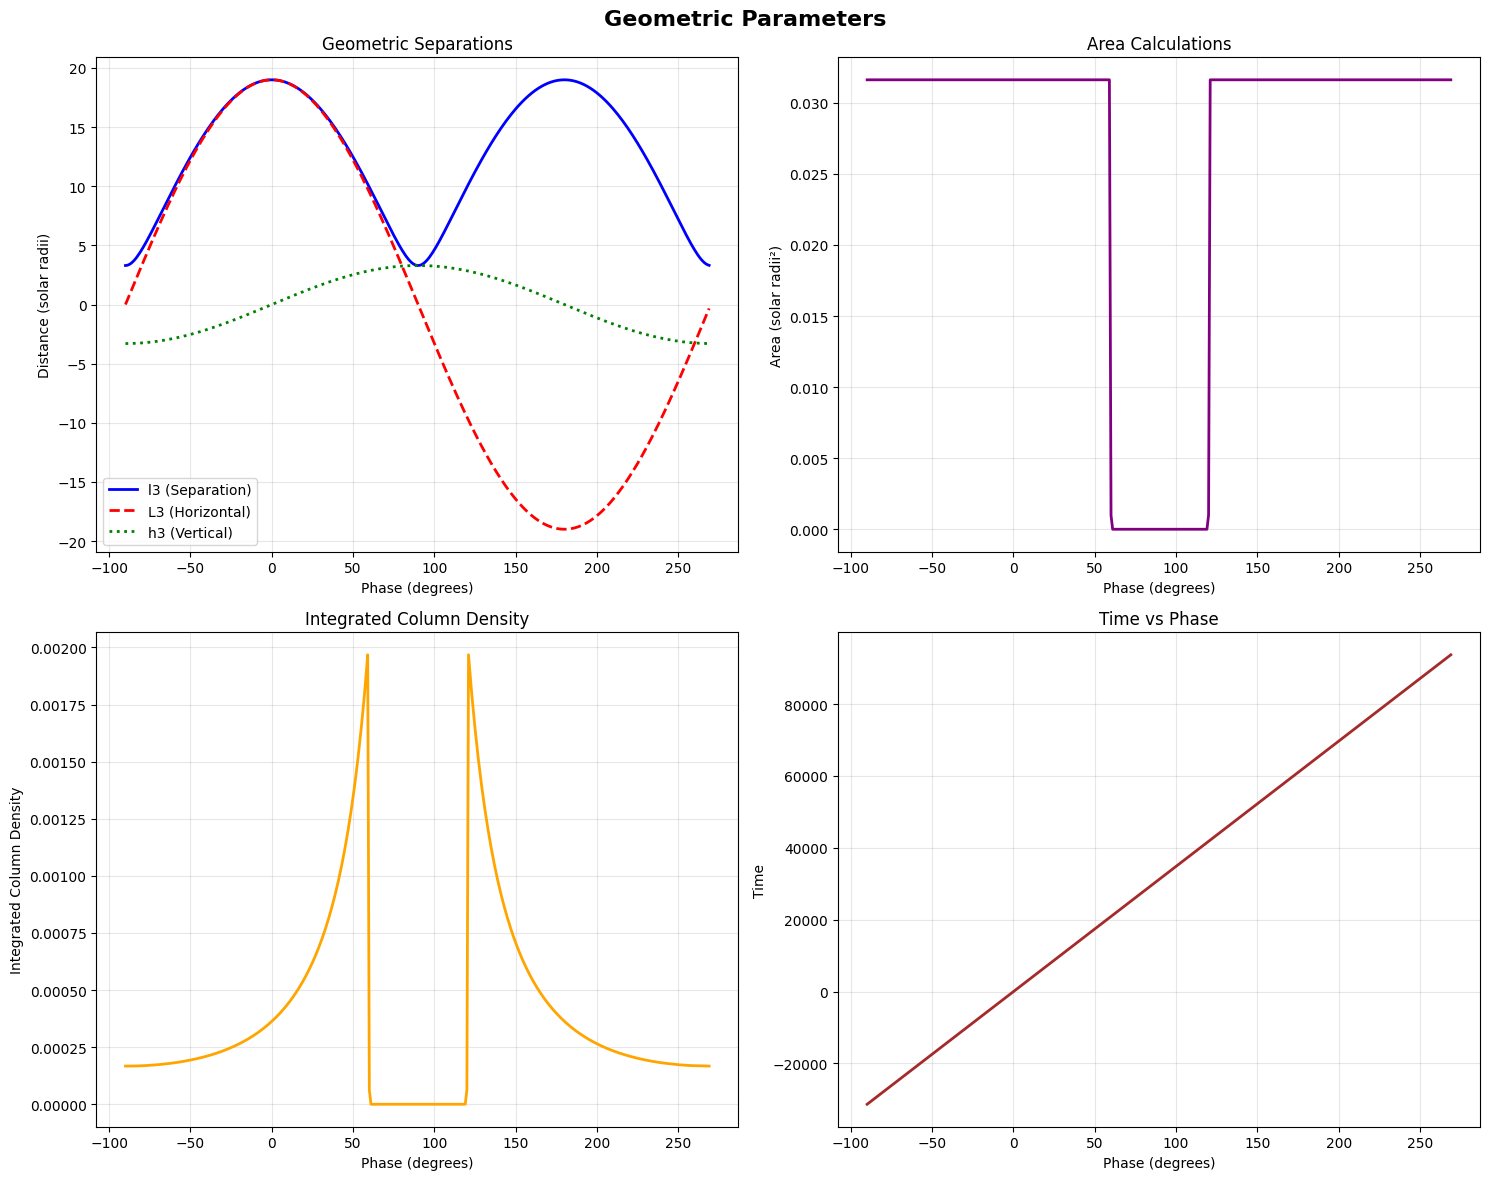

In [6]:
plot_geometric_parameters("sim_flux_interpolate_phabs_soft.csv")

## IC10X1 spectrum: XSpec model

In [2]:
from XRB_LightCurve.compute_flux_vs_nH import *
specdir = "XRB_LightCurve/data/IC10X1_spec"
instrument = "chandra"
src, bkg, rmf, arf = find_spectrum_files(specdir)
load_data(src, bkg, rmf, arf)


1 spectrum  in use
 
Spectral Data File: X1_spectrum_combined_src.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  6.920e-02 +/- 5.839e-04 (95.8 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: CHANDRA Instrument: ACIS  Channel Type: PI
  Exposure Time: 2.178e+05 sec
 Using fit statistic: chi
 Using Background File                X1_spectrum_combined_bkg.pi
  Background Exposure Time: 2.178e+05 sec
 Using Response (RMF) File            X1_spectrum_combined_src.rmf for Source 1
 Using Auxiliary Response (ARF) File  X1_spectrum_combined_src.arf

Net count rate (cts/s) for Spectrum:1  6.920e-02 +/- 5.839e-04 (95.8 % total)


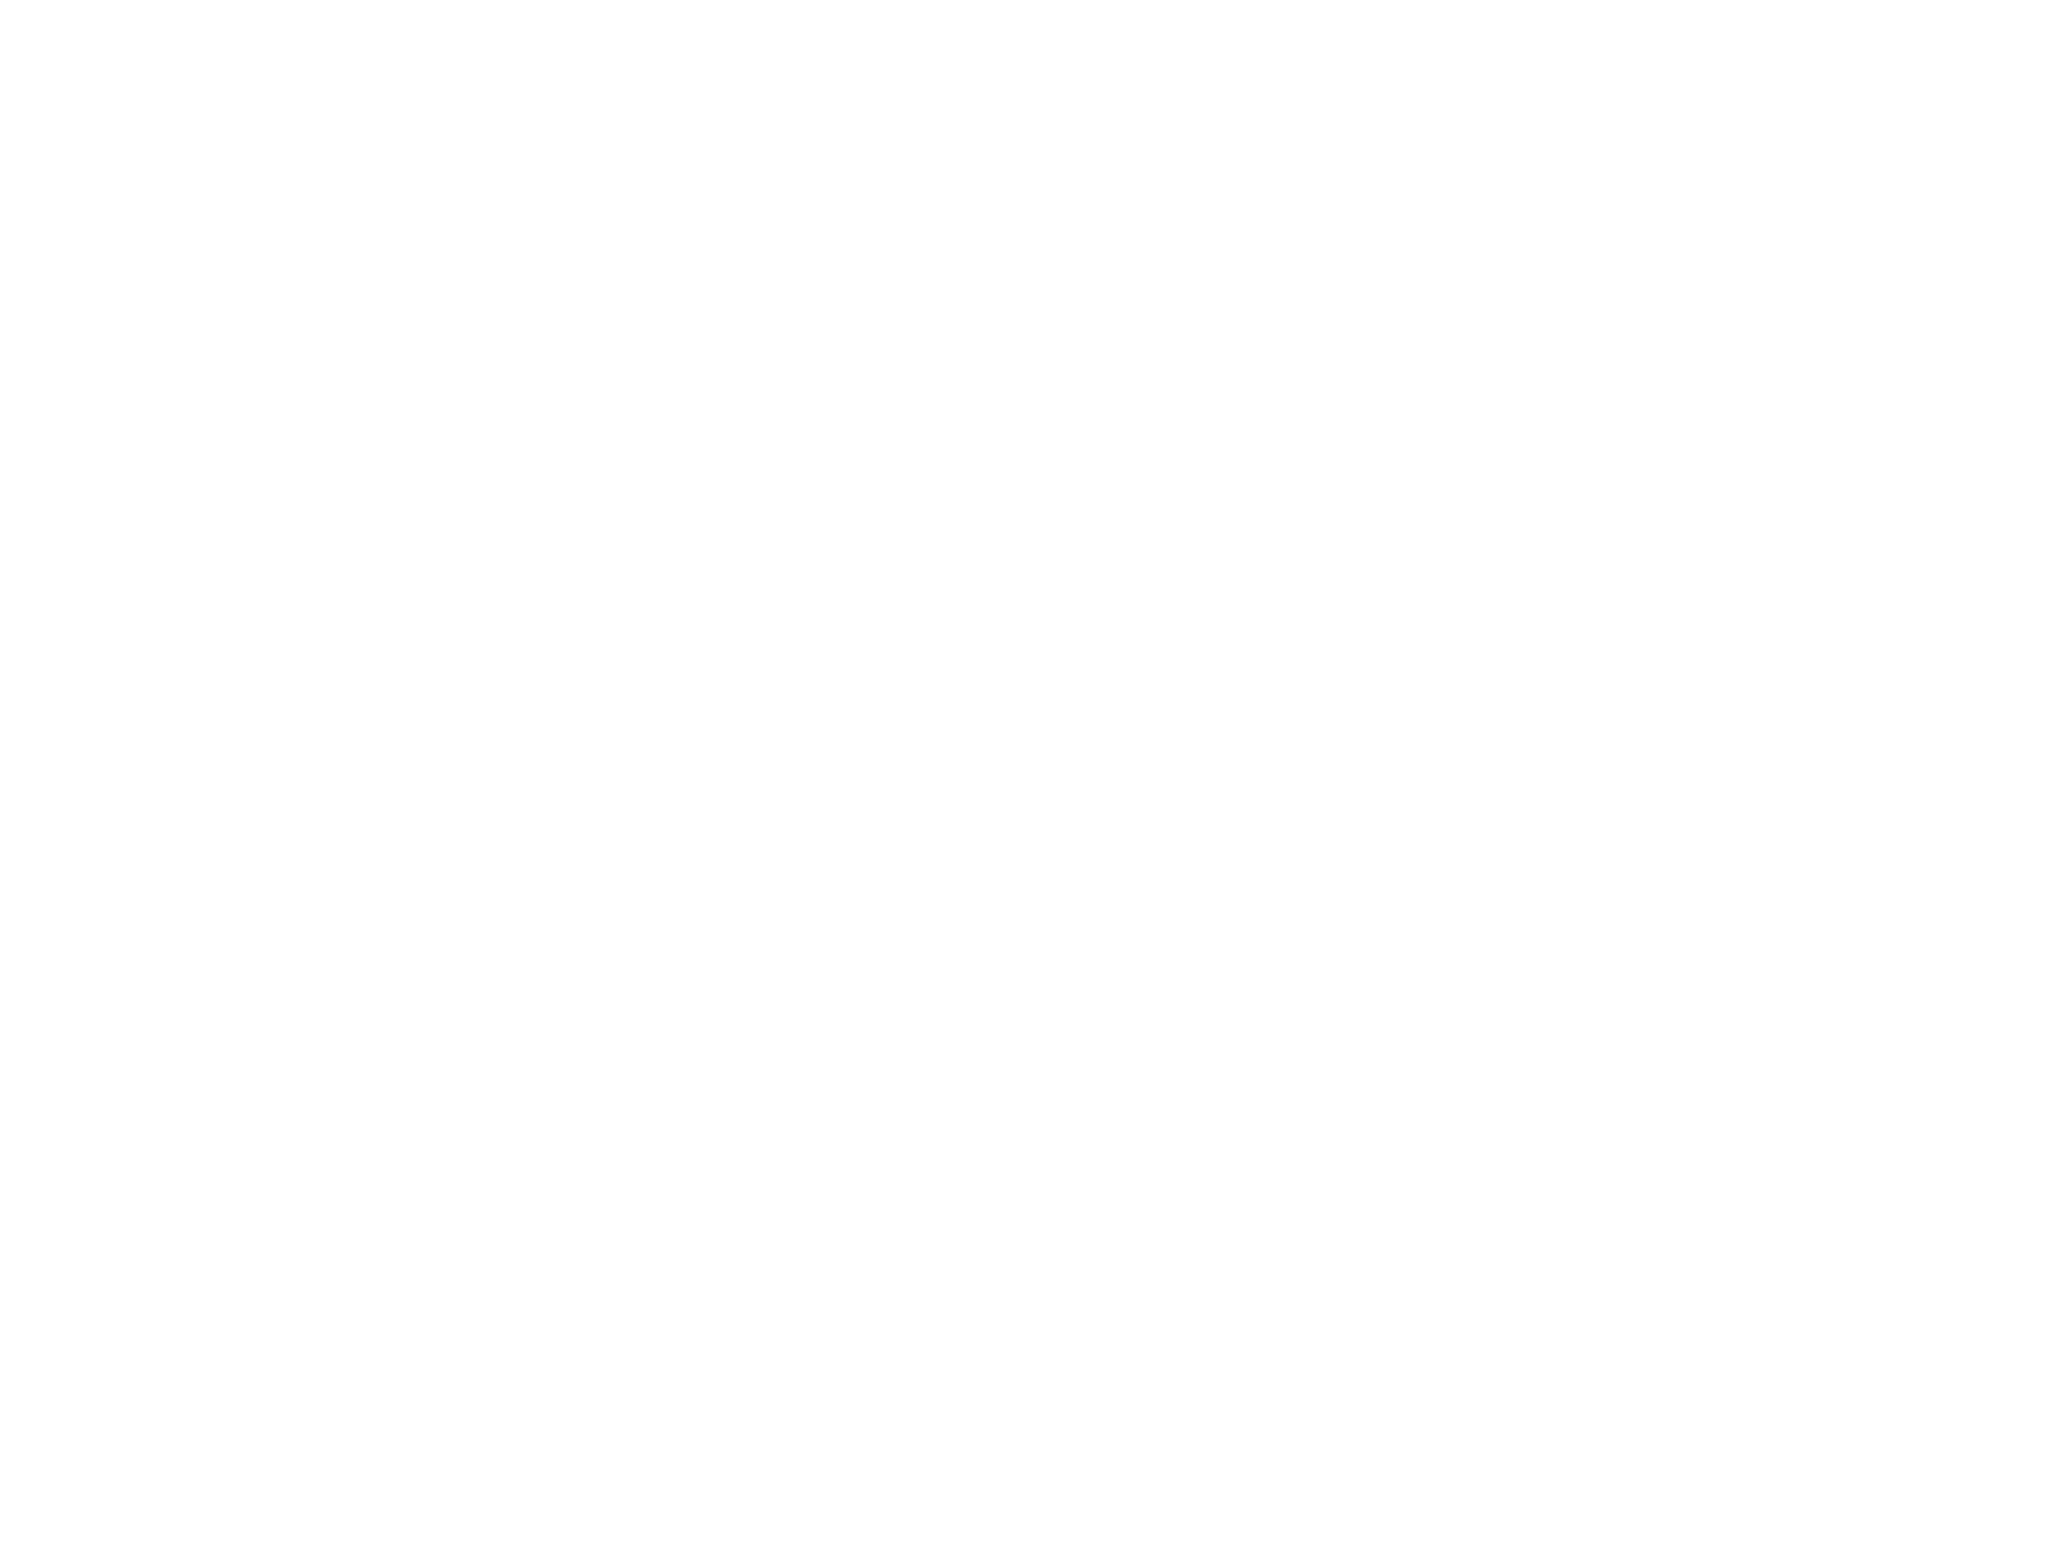

In [26]:
# Plot spectrum data
Plot.device = "/svg"
Plot.xAxis = "KeV"
Plot("data")

In [28]:
# Load an absorber model with powerlaw
m1 = Model("tbabs*po")
m1.powerlaw.PhoIndex = 1.92146
m1.powerlaw.norm = 3.37606e-04
m1.TBabs.nH = 0.5
m1.show()


Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              4.934301e+11     using 1024 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1

Test statistic : Chi-Squared              4.934301e+11     using 1024 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.000000e+00 with 1021 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared              6.576271e+10     using 1024 bins.

***Warning: Chi-square may 

In [29]:
# Fit model with data
Fit.perform()
Fit.show()

                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH    2:PhoIndex        3:norm
989.207      589.661      -3      0.575882       1.93218   0.000341094
989.057      1358.37      -4      0.571826       1.92058   0.000337217
989.054      746.803      -5      0.572695       1.92193   0.000337807
 Variances and Principal Axes
                 1        2        3  
 8.6421E-12| -0.0003  -0.0002   1.0000  
 5.7882E-05|  0.9276  -0.3735   0.0002  
 9.3425E-04|  0.3735   0.9276   0.0003  
----------------------------------------

  Covariance Matrix
        1           2           3   
   1.801e-04   3.036e-04   1.234e-07
   3.036e-04   8.120e-04   2.728e-07
   1.234e-07   2.728e-07   1.071e-10
------------------------------------

Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.572695     +/-  1.34211E-02  
   2    2   powerlaw   PhoIndex           